In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
DATA_DIR = r"C:\Users\shrey\Training Practicals\archive(project_QM9)\dsgdb9nsd.xyz"
MAX_FILES = 500
RANDOM_STATE = 42

In [3]:
def load_qm9(data_dir, max_files):
    files = [f for f in os.listdir(data_dir) if f.endswith(".xyz")][:max_files]
    records = []

    for file in files:
        with open(os.path.join(data_dir, file)) as f:
            lines = f.readlines()

        try:
            num_atoms = int(lines[0].strip())
        except:
            continue

        values = []
        for token in lines[1].split():
            try:
                values.append(float(token))
            except:
                pass

        if len(values) < 5:
            continue

        energy = values[-5]  # U0 energy

        atom_counts = {"C":0, "H":0, "O":0, "N":0, "F":0}
        for line in lines[2:2 + num_atoms]:
            atom = line.split()[0]
            if atom in atom_counts:
                atom_counts[atom] += 1

        records.append({
            "num_atoms": num_atoms,
            **atom_counts,
            "energy": energy
        })

    return pd.DataFrame(records)

In [4]:
df = load_qm9(DATA_DIR, MAX_FILES)
df.head()

,num_atoms,C,H,O,N,F,energy
0,5,1,4,0,0,0,-40.478930
1,4,0,3,0,1,0,-56.525887
2,3,0,2,1,0,0,-76.404702
3,4,2,2,0,0,0,-77.308427
4,3,1,1,0,1,0,-93.411888


In [5]:
# Molecular weight
df["molecular_weight"] = (
    12.01 * df["C"] +
    1.008 * df["H"] +
    16.00 * df["O"] +
    14.01 * df["N"] +
    19.00 * df["F"]
)

# Heavy atom count
df["heavy_atoms"] = df["C"] + df["O"] + df["N"] + df["F"]

# Atom ratios (safe division)
df["H_C_ratio"] = df["H"] / df["C"].replace(0, np.nan)
df["O_C_ratio"] = df["O"] / df["C"].replace(0, np.nan)
df["N_C_ratio"] = df["N"] / df["C"].replace(0, np.nan)
df["F_C_ratio"] = df["F"] / df["C"].replace(0, np.nan)

df.fillna(0, inplace=True)

In [6]:
def to_formula(row):
    formula = ""
    for atom in ["C", "H", "O", "N", "F"]:
        count = int(row[atom])
        if count > 0:
            formula += atom if count == 1 else f"{atom}{count}"
    return formula

df["formula"] = df.apply(to_formula, axis=1)

In [7]:
FEATURES = [
    "num_atoms",
    "C", "H", "O", "N", "F",
    "heavy_atoms",
    "molecular_weight",
    "H_C_ratio", "O_C_ratio", "N_C_ratio", "F_C_ratio"
]

X = df[FEATURES]
y = df["energy"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [9]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² :", r2_score(y_test, y_pred))

MAE: 2.7331283995967914
R² : 0.9844671163341091


In [17]:
y_pred

array([-323.64651023, -248.8193701 , -286.49977752, -195.3153867 ,
       -195.3153867 , -308.77785075, -286.49977752, -247.20179092,
       -268.26684028, -306.37925656, -125.38597464, -285.30178755,
       -270.4156945 , -233.55143306, -251.40477018, -343.41785014,
       -285.30178755, -185.15297882, -270.4156945 , -306.37925656,
       -270.9858494 , -297.51530736, -322.4527423 , -342.26443094,
       -268.26684028, -234.48569752, -301.38080323, -249.25384663,
       -218.83467772, -269.23137722, -307.57143584, -305.31983112,
       -321.25333958, -274.75409634,  -80.7847408 , -292.71527358,
       -306.37925656, -268.26684028, -301.38080323, -216.08182288,
       -271.63617004, -266.7150836 , -276.18996332, -321.25333958,
       -199.82021065, -272.93635853,  -82.8765112 , -148.19380437,
       -271.63617004, -164.89198343, -248.8193701 , -322.4527423 ,
       -268.26684028, -271.63617004, -265.30581061, -229.65288645,
       -196.70690987, -205.97039589, -265.30581061, -272.93635

In [11]:
importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
7,molecular_weight,0.732564
9,O_C_ratio,0.130282
1,C,0.036116
6,heavy_atoms,0.024493
3,O,0.018278
2,H,0.016801
0,num_atoms,0.009544
10,N_C_ratio,0.009005
8,H_C_ratio,0.007291
5,F,0.007171


In [12]:
def stability_level(energy):
    if energy < -200:
        return "High Stability"
    elif energy < -100:
        return "Medium Stability"
    else:
        return "Low Stability"

df["stability"] = df["energy"].apply(stability_level)

In [13]:
def energy_risk_score(energy):
    if energy > -80:
        return 3
    elif energy > -150:
        return 2
    else:
        return 1

def complexity_score(num_atoms):
    if num_atoms > 15:
        return 3
    elif num_atoms > 8:
        return 2
    else:
        return 1

def sustainability_score(energy, num_atoms):
    return (4 - energy_risk_score(energy)) + (4 - complexity_score(num_atoms))

df["energy_risk_score"] = df["energy"].apply(energy_risk_score)
df["complexity_score"] = df["num_atoms"].apply(complexity_score)

df["sustainability_score"] = df.apply(
    lambda x: sustainability_score(x["energy"], x["num_atoms"]),
    axis=1
)

In [14]:
df["energy_norm"] = (
    df["energy"] - df["energy"].min()
) / (df["energy"].max() - df["energy"].min())

df["complexity_norm"] = df["num_atoms"] / df["num_atoms"].max()
df["sustainability_norm"] = df["sustainability_score"] / df["sustainability_score"].max()

df["mo_score"] = (
    (1 - df["energy_norm"]) +
    (1 - df["complexity_norm"]) +
    df["sustainability_norm"]
)

In [15]:
def decision_readiness(score, stability):
    if score >= 6 and stability == "High Stability":
        return "Recommend"
    elif score >= 4:
        return "Investigate"
    else:
        return "Reject"

df["decision"] = df.apply(
    lambda x: decision_readiness(x["sustainability_score"], x["stability"]),
    axis=1
)

In [18]:
final_table = df[[
    # Identity
    "formula",
    
    # Core properties
    "energy",
    "num_atoms",
    "molecular_weight",
    "heavy_atoms",
    
    # Ratios
    "H_C_ratio", "O_C_ratio", "N_C_ratio", "F_C_ratio",
    
    # Scores
    "energy_risk_score",
    "complexity_score",
    "sustainability_score",
    "mo_score",
    
    # Labels
    "stability",
    "decision"
]].sort_values(
    by=["decision", "mo_score"],
    ascending=[True, False]
)

final_table.head(10)

,formula,energy,num_atoms,molecular_weight,heavy_atoms,H_C_ratio,O_C_ratio,N_C_ratio,F_C_ratio,energy_risk_score,complexity_score,sustainability_score,mo_score,stability,decision
24,C2N2,-185.648533,4,52.040,4,0.000000,0.000000,1.000000,0.0,1,1,6,2.165661,Medium Stability,Investigate
454,C3H4O3,-342.352279,10,88.062,6,1.333333,1.000000,0.000000,0.0,1,2,5,2.093708,High Stability,Investigate
451,C3H4O3,-342.335241,10,88.062,6,1.333333,1.000000,0.000000,0.0,1,2,5,2.093665,High Stability,Investigate
355,C3H4O3,-342.329232,10,88.062,6,1.333333,1.000000,0.000000,0.0,1,2,5,2.093650,High Stability,Investigate
430,C3H4O3,-342.315546,10,88.062,6,1.333333,1.000000,0.000000,0.0,1,2,5,2.093616,High Stability,Investigate
341,C3H4O3,-342.307696,10,88.062,6,1.333333,1.000000,0.000000,0.0,1,2,5,2.093596,High Stability,Investigate
356,C3H4O3,-342.297848,10,88.062,6,1.333333,1.000000,0.000000,0.0,1,2,5,2.093571,High Stability,Investigate
187,C3H3O2N,-321.276274,9,85.064,6,1.000000,0.666667,0.333333,0.0,1,2,5,2.090621,High Stability,Investigate
440,C3H3O2N,-321.271406,9,85.064,6,1.000000,0.666667,0.333333,0.0,1,2,5,2.090609,High Stability,Investigate
349,C3H3O2N,-321.254976,9,85.064,6,1.000000,0.666667,0.333333,0.0,1,2,5,2.090567,High Stability,Investigate


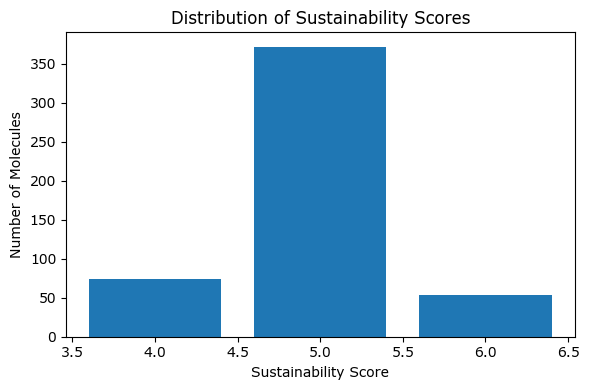

In [27]:
import matplotlib.pyplot as plt

score_counts = df["sustainability_score"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(score_counts.index, score_counts.values)
plt.xlabel("Sustainability Score")
plt.ylabel("Number of Molecules")
plt.title("Distribution of Sustainability Scores")
plt.tight_layout()
plt.show()

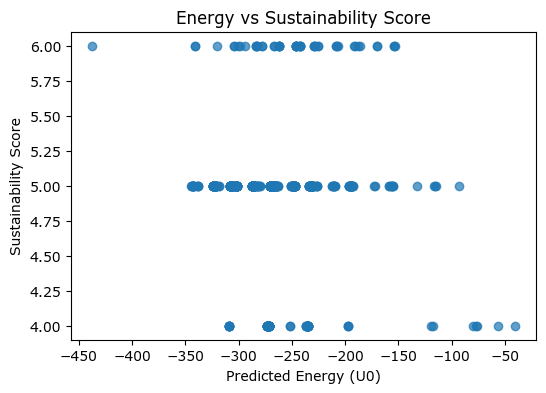

In [28]:
plt.figure(figsize=(6,4))
plt.scatter(df["energy"], df["sustainability_score"], alpha=0.7)
plt.xlabel("Predicted Energy (U0)")
plt.ylabel("Sustainability Score")
plt.title("Energy vs Sustainability Score")
plt.show()

# test dataset

In [22]:
import numpy as np

test_df["heavy_atoms"] = test_df["C"] + test_df["O"] + test_df["N"] + test_df["F"]

test_df["molecular_weight"] = (
    12.01 * test_df["C"] +
    1.008 * test_df["H"] +
    16.00 * test_df["O"] +
    14.01 * test_df["N"] +
    19.00 * test_df["F"]
)

test_df["H_C_ratio"] = test_df["H"] / test_df["C"].replace(0, np.nan)
test_df["O_C_ratio"] = test_df["O"] / test_df["C"].replace(0, np.nan)
test_df["N_C_ratio"] = test_df["N"] / test_df["C"].replace(0, np.nan)
test_df["F_C_ratio"] = test_df["F"] / test_df["C"].replace(0, np.nan)

test_df.fillna(0, inplace=True)

In [23]:
FEATURES = [
    "num_atoms", "C", "H", "O", "N", "F",
    "heavy_atoms", "molecular_weight",
    "H_C_ratio", "O_C_ratio", "N_C_ratio", "F_C_ratio"
]

test_df["energy"] = model.predict(test_df[FEATURES])

In [24]:
predicted_energy

array([ -95.11420225, -193.60373057, -210.19476053, -298.89464228])

In [25]:
# Identity
test_df["formula"] = test_df.apply(to_formula, axis=1)

# Rule-based scores
test_df["energy_risk_score"] = test_df["energy"].apply(energy_risk_score)
test_df["complexity_score"] = test_df["num_atoms"].apply(complexity_score)

test_df["sustainability_score"] = test_df.apply(
    lambda x: sustainability_score(x["energy"], x["num_atoms"]),
    axis=1
)

# Normalization (IMPORTANT: use TRAIN df stats)
test_df["energy_norm"] = (
    test_df["energy"] - df["energy"].min()
) / (df["energy"].max() - df["energy"].min())

test_df["complexity_norm"] = test_df["num_atoms"] / df["num_atoms"].max()

test_df["sustainability_norm"] = (
    test_df["sustainability_score"] / df["sustainability_score"].max()
)

# Multi-objective score
test_df["mo_score"] = (
    (1 - test_df["energy_norm"]) +
    (1 - test_df["complexity_norm"]) +
    test_df["sustainability_norm"]
)

# Stability + Final decision
test_df["stability"] = test_df["energy"].apply(stability_level)

test_df["decision"] = test_df.apply(
    lambda x: decision_readiness(x["sustainability_score"], x["stability"]),
    axis=1
)

In [26]:
test_final_table = test_df[[
    "formula",
    "num_atoms",
    "molecular_weight",
    "heavy_atoms",
    "H_C_ratio", "O_C_ratio", "N_C_ratio", "F_C_ratio",
    "energy",
    "energy_risk_score",
    "complexity_score",
    "sustainability_score",
    "mo_score",
    "stability",
    "decision"
]]

test_final_table

,formula,num_atoms,molecular_weight,heavy_atoms,H_C_ratio,O_C_ratio,N_C_ratio,F_C_ratio,energy,energy_risk_score,complexity_score,sustainability_score,mo_score,stability,decision
0,C2H4,6,28.052,2,2.00,0.000000,0.00,0.0,-95.114202,2,1,5,1.670952,Low Stability,Investigate
1,C3H6O,9,58.078,4,2.00,0.333333,0.00,0.0,-193.603731,1,2,5,1.769032,Medium Stability,Investigate
2,C4H5N,10,67.090,5,1.25,0.000000,0.25,0.0,-210.310065,1,2,5,1.761113,High Stability,Investigate
3,C4H4F4,12,128.072,8,1.00,0.000000,0.00,1.0,-298.894642,1,2,5,1.884245,High Stability,Investigate
